# Question 4: Classify handwritten digits

Run from `homework/week-05` (the folder containing `data`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/opt/homebrew/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
train = pd.read_csv("data/knn/zip-train.csv.gz", header=None).iloc[:1000]
test = pd.read_csv("data/knn/zip-test.csv.gz", header=None).iloc[:500]

X_train = train.iloc[:, 1:].to_numpy()
y_train = train.iloc[:, 0].to_numpy().astype(int)
X_test = test.iloc[:, 1:].to_numpy()
y_test = test.iloc[:, 0].to_numpy().astype(int)

X_train.shape, X_test.shape

((1000, 256), (500, 256))

## (a) 5NN classifier

In [11]:
def knn5_classify(X_train, y_train, X_test, metric="euclidean", k=5):
    preds = np.empty(len(X_test), dtype=int)
    for t, x0 in enumerate(X_test):
        diff = X_train - x0
        if metric == "euclidean":
            dist = np.sqrt(np.sum(diff ** 2, axis=1))
        elif metric == "manhattan":
            dist = np.sum(np.abs(diff), axis=1)
        else:
            raise ValueError("metric must be 'euclidean' or 'manhattan'")
        # stable sort: equal distances keep the smaller training row first
        nearest = np.argsort(dist, kind="stable")[:k]
        votes = np.bincount(y_train[nearest], minlength=10)
        # argmax returns the first maximum, i.e. the smallest tied digit
        preds[t] = np.argmax(votes)
    return preds

## (b) Test error and confusion matrices

In [4]:
pred_e = knn5_classify(X_train, y_train, X_test, "euclidean")
pred_m = knn5_classify(X_train, y_train, X_test, "manhattan")

def confusion(pred, truth):
    cm = pd.crosstab(pd.Categorical(pred, categories=range(10)),
                     pd.Categorical(truth, categories=range(10)),
                     rownames=["predicted"], colnames=["true"], dropna=False)
    return cm

err_e = np.mean(pred_e != y_test)
err_m = np.mean(pred_m != y_test)
pd.DataFrame({"distance": ["Euclidean", "Manhattan"],
              "test error": [err_e, err_m],
              "misclassified": [(pred_e != y_test).sum(), (pred_m != y_test).sum()]})

,distance,test error,misclassified
0,Euclidean,0.122,61
1,Manhattan,0.138,69


In [12]:
cm_e = confusion(pred_e, y_test)
print(cm_e.style.to_typst())

#table(
  columns: 11,
  [true], [0], [1], [2], [3], [4], [5], [6], [7], [8], [9],
  [predicted], [], [], [], [], [], [], [], [], [], [],

  [0], [118], [0], [7], [1], [0], [4], [2], [0], [2], [0],
  [1], [0], [66], [0], [0], [2], [0], [0], [0], [0], [1],
  [2], [0], [0], [39], [1], [0], [0], [2], [0], [0], [1],
  [3], [0], [0], [0], [23], [0], [4], [0], [0], [2], [0],
  [4], [0], [0], [1], [0], [27], [1], [1], [1], [0], [1],
  [5], [0], [0], [0], [1], [0], [13], [0], [0], [0], [0],
  [6], [0], [2], [0], [0], [0], [1], [41], [0], [2], [0],
  [7], [0], [0], [0], [0], [1], [1], [0], [34], [0], [4],
  [8], [0], [0], [3], [2], [0], [2], [0], [0], [37], [0],
  [9], [1], [0], [0], [1], [4], [0], [0], [1], [1], [41],
)


In [6]:
cm_m = confusion(pred_m, y_test)
cm_m

true,0,1,2,3,4,5,6,7,8,9
predicted,,,,,,,,,,
0,118,0,6,1,0,5,3,0,4,0
1,0,67,2,0,2,0,1,0,0,1
2,0,0,35,0,0,0,2,0,0,0
3,0,0,1,24,0,4,0,0,2,0
4,0,0,1,1,27,1,0,1,0,1
5,0,0,0,1,0,11,0,0,0,0
6,0,1,0,0,0,2,40,0,2,0
7,0,0,2,1,1,0,0,34,0,5
8,0,0,2,0,0,3,0,0,34,0


In [14]:
def top_confusions(cm, n=5):
    m = cm.to_numpy()
    pairs = [(i, j, m[i, j] + m[j, i], m[i, j], m[j, i])
             for i in range(10) for j in range(i + 1, 10)]
    out = pd.DataFrame(pairs, columns=["digit a", "digit b", "total",
                                       "pred a / true b", "pred b / true a"])
    return out.sort_values("total", ascending=False).head(n).reset_index(drop=True)

a = pd.concat({"Euclidean": top_confusions(cm_e), "Manhattan": top_confusions(cm_m)}, axis=1)
print(a.style.to_typst())

#table(
  columns: 11,
  [], [Euclidean], [], [], [], [], [Manhattan], [], [], [], [],
  [], [digit a], [digit b], [total], [pred a / true b], [pred b / true a], [digit a], [digit b], [total], [pred a / true b], [pred b / true a],

  [0], [0], [2], [7], [7], [0], [7], [9], [6], [5], [1],
  [1], [4], [9], [5], [1], [4], [0], [2], [6], [6], [0],
  [2], [7], [9], [5], [4], [1], [0], [5], [5], [5], [0],
  [3], [3], [5], [5], [4], [1], [4], [9], [5], [1], [4],
  [4], [0], [5], [4], [4], [0], [3], [5], [5], [4], [1],
)


**Errors.** Euclidean 5NN misclassifies 61 of 500 test images (test error 0.122); Manhattan 5NN misclassifies 69 (test error 0.138).

**Most confused digits.** Rows are predicted and columns are true digits. With Euclidean distance the largest off-diagonal cell is true 2 predicted as 0 (7 images), and the most confused pairs overall are 0/2 (7), then 4/9, 7/9 and 3/5 (5 each) and 0/5 (4). Manhattan shows the same pattern: 0/2 and 0/8 (6 each), then 0/5, 4/9 and 3/5 (5 each). The recurring pairs are digits with similar strokes: a 2 with a closed bottom loop resembles a 0, 4 and 9 share an upper loop or triangle over a vertical stroke, 7 and 9 share a top bar with a descending stroke, and 3 and 5 share the same lower curve. Both classifiers also over-predict 0 (row 0 sums to 134 and 137 versus 119 true zeros), because 0 is the most common training digit and has a large, heavy shape that many poorly written digits land near.

## (c) Misclassified images and comparison

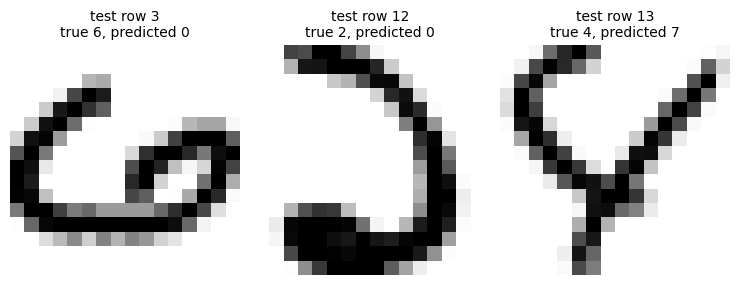

In [8]:
wrong_e = np.where(pred_e != y_test)[0]
show = wrong_e[:3]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.8))
for ax, i in zip(axes, show):
    ax.imshow(X_test[i].reshape(16, 16), cmap="gray_r")
    ax.set_title(f"test row {i}\ntrue {y_test[i]}, predicted {pred_e[i]}", fontsize=10)
    ax.axis("off")
fig.tight_layout()
plt.savefig("q4c.png", dpi=200, bbox_inches="tight")
plt.show()

**Are the mistakes understandable?** Mostly, yes. Row 3 is a 6 written tilted and nearly flat, so its bottom loop dominates and it looks like a closed oval, i.e. a 0. Row 12 is a 2 whose lower stroke is thick and curls back, so the ink traces almost a full ring, again close to a 0 in pixel space. Row 13 is a 4 drawn open like a check mark, with a long diagonal arm reaching the top right; that diagonal is exactly what a 7 has, so its nearest neighbors being 7s is not surprising. A human would still read these correctly, but because KNN compares raw pixel intensities, a shifted, rotated, or unusually thick stroke moves an image toward the wrong class.

In [17]:
wrong_m = pred_m != y_test
we = pred_e != y_test
a = pd.DataFrame({
    "case": ["both wrong", "  ...same wrong label", "  ...different wrong labels",
             "only Euclidean wrong", "only Manhattan wrong", "both correct"],
    "count": [(we & wrong_m).sum(),
              (we & wrong_m & (pred_e == pred_m)).sum(),
              (we & wrong_m & (pred_e != pred_m)).sum(),
              (we & ~wrong_m).sum(), (~we & wrong_m).sum(), (~we & ~wrong_m).sum()]})

print(a.style.to_typst())

#table(
  columns: 3,
  [], [case], [count],

  [0], [both wrong], [58],
  [1], [  ...same wrong label], [50],
  [2], [  ...different wrong labels], [8],
  [3], [only Euclidean wrong], [3],
  [4], [only Manhattan wrong], [11],
  [5], [both correct], [428],
)


In [16]:
disagree = np.where(we != wrong_m)[0]
pd.DataFrame({"test row": disagree, "true": y_test[disagree],
              "Euclidean": pred_e[disagree], "Manhattan": pred_m[disagree]})

,test row,true,Euclidean,Manhattan
0,32,5,5,0
1,63,2,2,7
2,154,8,8,9
3,233,1,6,1
4,234,2,2,1
5,241,5,5,6
6,264,8,8,0
7,269,8,8,0
8,311,5,5,3
9,338,6,6,0


**Comparing the two distances.** The overall results are similar: 0.122 (Euclidean) versus 0.138 (Manhattan), and the two confusion matrices have nearly the same structure. The predictions agree on 478 of the 500 images.

**Similar total error, different mistakes?** Yes. The two error sets overlap heavily but not completely: 58 images are misclassified by both, 3 only by Euclidean (e.g. rows 233, 380, 437) and 11 only by Manhattan (e.g. rows 32, 63, 154, 264). Even among the 58 shared errors, 8 receive *different* wrong labels (for example a true 2 is sent to one wrong digit by one metric and to another by the other). So a total error of 61 versus 69 hides 14 images where exactly one method is right, plus 8 where both are wrong in different ways. This happens because Euclidean distance squares pixel differences and so is dominated by a few large mismatches (e.g. a stroke in a different place), while Manhattan weights every pixel difference linearly and is more influenced by many small intensity differences; for borderline images this can change which five training images are nearest. Total error alone therefore cannot tell us whether two classifiers make the same mistakes; comparing the predictions image by image is needed.